In [1]:
import shap
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


C:\Users\Y.PHANI MANJUNATH\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:


model = joblib.load(r"C:\Users\Y.PHANI MANJUNATH\OneDrive\Desktop\ML_PROJECT\fraud-detection\models\best_model.pkl")

X_test = np.load(r"C:\Users\Y.PHANI MANJUNATH\OneDrive\Desktop\ML_PROJECT\fraud-detection\models\X_test.npy")
y_test = np.load(r"C:\Users\Y.PHANI MANJUNATH\OneDrive\Desktop\ML_PROJECT\fraud-detection\models\y_test.npy")

feature_names = ['Time', 'V1','V2','V3','V4','V5','V6','V7','V8','V9',
                 'V10','V11','V12','V13','V14','V15','V16','V17','V18',
                 'V19','V20','V21','V22','V23','V24','V25','V26','V27',
                 'V28','Amount']

X_test_df = pd.DataFrame(X_test, columns=feature_names)


print("X_test shape:", X_test_df.shape)

X_test shape: (56962, 30)


In [4]:
X_test_df.shape

(56962, 30)

In [7]:
#SHAP EXPLAINER

In [8]:
explainer=shap.TreeExplainer(model)

In [9]:
explainer

In [10]:
shap_values=explainer.shap_values(X_test_df)

In [14]:
np.array(shap_values).shape

(56962, 30)

In [12]:
shap_values.shape

(56962, 30)

In [13]:
shap_values[1]

array([-0.27912283,  0.1044359 ,  0.04061809, -1.04955423, -1.47123714,
        0.01723793, -0.02393287,  0.24533262,  0.12032259,  0.08673662,
       -0.94982197,  0.07546154, -0.21425438, -0.17355633, -3.50177006,
        0.05639464, -0.19496175, -0.6801194 , -0.01302241, -0.02893891,
        0.16182282, -0.1702067 , -0.07253316, -0.0898463 ,  0.02098541,
        0.06761881,  0.01421988, -0.08404288, -0.22693723, -0.19000989])

In [17]:
print(type(shap_values))

<class 'numpy.ndarray'>


In [18]:
print(np.array(shap_values).shape)

(56962, 30)


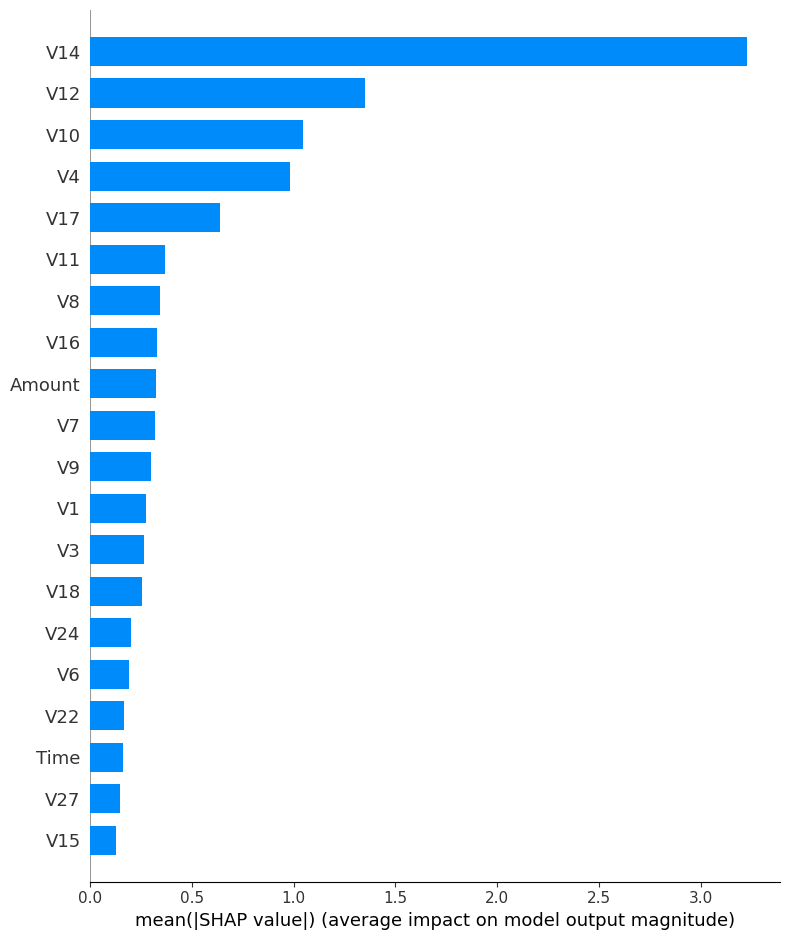

In [19]:
shap.summary_plot(shap_values,X_test_df,plot_type='bar')

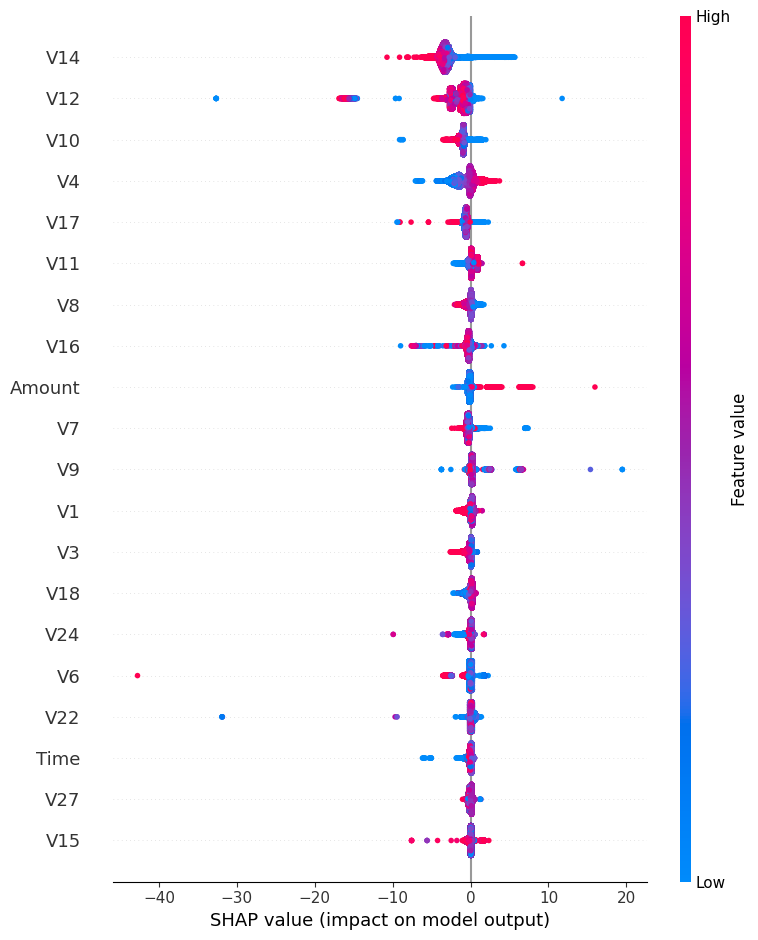

In [20]:
shap.summary_plot(shap_values,X_test_df)

In [23]:
import pandas as pd
import joblib
import numpy as np

# Load data
df = pd.read_csv(r"C:\Users\Y.PHANI MANJUNATH\OneDrive\Desktop\ML_PROJECT\fraud-detection\data\creditcard.csv")

# Load model
model = joblib.load(r"C:\Users\Y.PHANI MANJUNATH\OneDrive\Desktop\ML_PROJECT\fraud-detection\models\best_model.pkl")

# Filter fraud
fraud_df = df[df['Class'] == 1]

# Take a real fraud sample
fraud_sample = fraud_df.sample(1).copy()
print("Real Class:", fraud_sample['Class'].values[0])

# Predict directly
features = fraud_sample.drop('Class', axis=1).values
pred = model.predict(features)[0]
prob = model.predict_proba(features)[0][1]

print("Prediction:", pred)
print("Probability:", prob)

Real Class: 1
Prediction: 1
Probability: 0.9998970952607658
